# Phase 2 — Baseline Spatial CNN (EfficientNetB0)

**Objective:** Train a CNN using raw RGB spatial features as the baseline. This establishes a performance ceiling for spatial-only learning. Its weaknesses will motivate the frequency-domain approach in Phase 4–7.

**Architecture:** EfficientNetB0 pretrained on ImageNet → GlobalAveragePooling → Dropout → Binary Output  
**Input:** RGB images resized to 128 × 128  
**Training strategy:** Frozen backbone (5 epochs) → Fine-tune top 20 layers (5 epochs)

## Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-05-28 13:21:47.383763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779974507.632207      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779974507.701776      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779974508.271894      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779974508.271950      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779974508.271954      23 computation_placer.cc:177] computation placer alr

## Configuration & Paths

In [2]:
BASE_PATH      = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TRAIN_PATH     = os.path.join(BASE_PATH, "train")
TEST_PATH      = os.path.join(BASE_PATH, "test")
RESULT_DIR     = "/kaggle/working/results/baseline_spatial"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
MODEL_DIR      = "/kaggle/working/models"

os.makedirs(RESULT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,      exist_ok=True)

IMG_SIZE        = (128, 128)
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 10

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Build Data Generators

Images are rescaled to [0, 1]. The training set is split 80/20 into training and validation subsets using `validation_split`. The test generator uses `shuffle=False` to preserve label alignment during evaluation.

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", subset="training", shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", subset="validation", shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", shuffle=False
)

print("Class indices :", train_gen.class_indices)

Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Class indices : {'FAKE': 0, 'REAL': 1}


## Verify Batch Shape

In [4]:
X_batch, y_batch = next(train_gen)

print("Image batch shape :", X_batch.shape)
print("Label batch shape :", y_batch.shape)
print("Pixel range       :", X_batch.min().round(3), "to", X_batch.max().round(3))

Image batch shape : (32, 128, 128, 3)
Label batch shape : (32,)
Pixel range       : 0.0 to 1.0


## Build Model

EfficientNetB0 is selected as the backbone: it is computationally efficient, well-suited to Kaggle GPU limits, and strong at image classification. ImageNet weights give the model prior knowledge of edges, textures, and shapes. The top layers are replaced with a binary classification head.

In [5]:
backbone = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)
backbone.trainable = False

model = Sequential([
    backbone,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1779974594.507672      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779974594.513760      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Define Model Checkpoint Callback

In [6]:
checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "baseline_spatial_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

## Train — Frozen Backbone

The backbone is kept frozen so only the classification head learns first. This prevents large gradient updates from corrupting pretrained weights before the head is stable.

In [7]:
history_frozen = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=[checkpoint_cb]
)

model.save(os.path.join(MODEL_DIR, "baseline_spatial_after_frozen.keras"))
print("Frozen-stage model saved immediately.")
print("Go to Kaggle Output panel and download baseline_spatial_after_frozen.keras now if needed.")

Epoch 1/10


I0000 00:00:1779974608.508979      91 service.cc:152] XLA service 0x7884b8003910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779974608.509026      91 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779974608.509031      91 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779974610.999397      91 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-28 13:23:38.235163: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 13:23:38.369041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 13:23:38.694833: E external/local_xl

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5026 - loss: 0.6994
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /kaggle/working/checkpoints/baseline_spatial_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/baseline_spatial_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 436s 163ms/step - accuracy: 0.5034 - loss: 0.6984 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5089 - loss: 0.6961
Epoch 2: val_accuracy improved from 0.50000 to 0.50005, saving model to /kaggle/working/checkpoints/baseline_spatial_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/baseline_spatial_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 108s 43ms/step - accuracy: 0.5086 - loss: 0.6966 - val_accuracy: 0.5001 - val_loss: 0.6916
Epoch 3/10
2499/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5093 - loss: 0.6968
Epoch 3: val_accuracy improved from 0.50005 to 0.63135, saving 

## Verify Checkpoint Saved

Confirms the best checkpoint from frozen training exists on disk before fine-tuning begins. 
If this shows MISSING, do not proceed to fine-tuning.

In [8]:
import os

checkpoint_path = os.path.join(CHECKPOINT_DIR, "baseline_spatial_best.keras")
frozen_path     = os.path.join(MODEL_DIR, "baseline_spatial_after_frozen.keras")

for label, path in [("Best checkpoint", checkpoint_path), ("Frozen-stage save", frozen_path)]:
    exists = os.path.exists(path)
    size   = round(os.path.getsize(path) / (1024*1024), 2) if exists else 0
    status = "OK" if exists else "MISSING — DO NOT CONTINUE"
    print(f"{label:<22} : {status}  ({size} MB)")

Best checkpoint        : OK  (16.27 MB)
Frozen-stage save      : OK  (16.27 MB)


## Fine-Tune — Unfreeze Top 20 Backbone Layers

The top 20 layers of EfficientNetB0 are unfrozen and retrained at a lower learning rate (1e-5). This allows the model to adapt high-level features to the deepfake detection task without overwriting the lower-level texture and edge representations.

In [9]:
backbone.trainable = True
for layer in backbone.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=[checkpoint_cb, earlystop_cb]
)

model.save(os.path.join(MODEL_DIR, "baseline_spatial_after_finetune.keras"))
print("Fine-tuned model saved immediately.")
print("Go to Kaggle Output panel and download baseline_spatial_after_finetune.keras now if needed.")

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5318 - loss: 0.7148
Epoch 1: val_accuracy did not improve from 0.63135
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 172s 58ms/step - accuracy: 0.5456 - loss: 0.6988 - val_accuracy: 0.5139 - val_loss: 0.6901
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5843 - loss: 0.6720
Epoch 2: val_accuracy improved from 0.63135 to 0.68945, saving model to /kaggle/working/checkpoints/baseline_spatial_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/baseline_spatial_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 147s 59ms/step - accuracy: 0.5922 - loss: 0.6673 - val_accuracy: 0.6895 - val_loss: 0.6277
Epoch 3/10
2499/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6228 - loss: 0.6486
Epoch 3: val_accuracy did not improve from 0.68945
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 136s 54ms/step - accuracy: 0.6238 - loss: 0.6449 - val_accuracy: 0.6323 - val_loss: 0.6296
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 4

## Plot Training History

Both training phases are concatenated for a continuous view. The dashed vertical line marks the transition from frozen to fine-tune training.

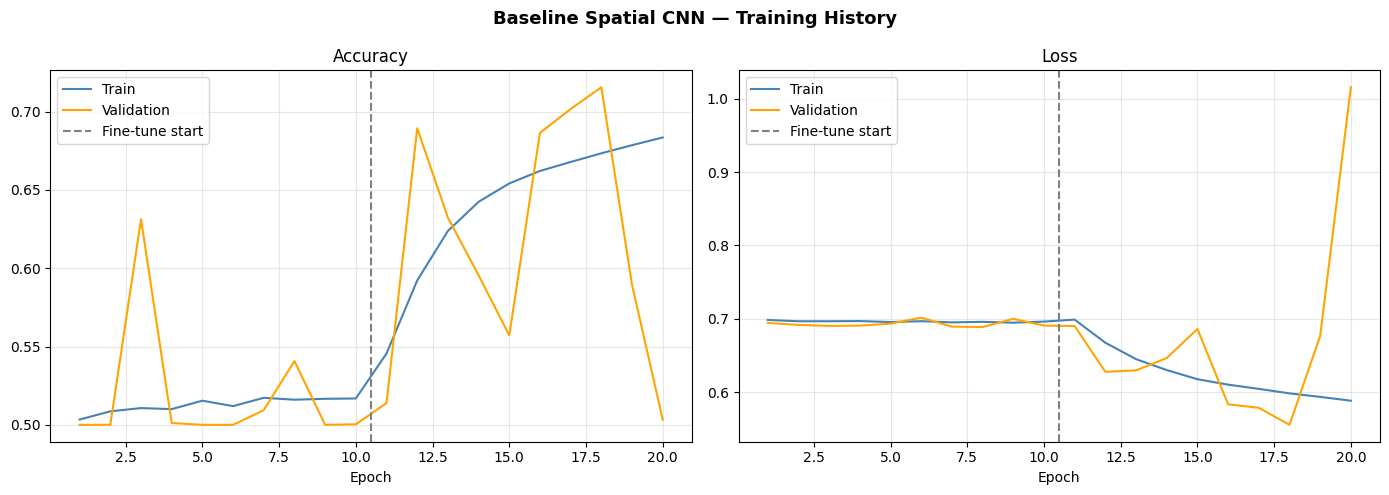

In [10]:
acc      = history_frozen.history["accuracy"]     + history_finetune.history["accuracy"]
val_acc  = history_frozen.history["val_accuracy"] + history_finetune.history["val_accuracy"]
loss     = history_frozen.history["loss"]         + history_finetune.history["loss"]
val_loss = history_frozen.history["val_loss"]     + history_finetune.history["val_loss"]
epochs_x = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline Spatial CNN — Training History", fontsize=13, fontweight="bold")

for ax, train_vals, val_vals, title in [
    (axes[0], acc,  val_acc,  "Accuracy"),
    (axes[1], loss, val_loss, "Loss"),
]:
    ax.plot(epochs_x, train_vals, label="Train",      color="steelblue")
    ax.plot(epochs_x, val_vals,   label="Validation", color="orange")
    ax.axvline(x=EPOCHS_FROZEN + 0.5, color="gray", linestyle="--", label="Fine-tune start")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "training_history.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save Final Model

In [11]:
import os

final_path = os.path.join(MODEL_DIR, "baseline_spatial_final.keras")
model.save(final_path)

size_mb = round(os.path.getsize(final_path) / (1024 * 1024), 2)
print(f"Model saved : {final_path}")
print(f"File size   : {size_mb} MB")
print()
print("Go to Kaggle Output panel now and download baseline_spatial_final.keras")

Model saved : /kaggle/working/models/baseline_spatial_final.keras
File size   : 26.59 MB

Go to Kaggle Output panel now and download baseline_spatial_final.keras


---
## Phase 2 Complete

| Step | Detail |
|---|---|
| Backbone | EfficientNetB0 (ImageNet weights) |
| Input | 128 × 128 RGB |
| Frozen training | 10 epochs @ lr=1e-3 |
| Fine-tune training | 10 epochs @ lr=1e-5 (top 20 layers) |
| Output | Binary sigmoid (REAL / FAKE) |

**Next → Phase 3: Baseline Evaluation**

## Download Phase 2 Outputs

Run this cell after training is complete. The `.keras` model file is required by Phase 3 and Phase 8 & 9.

In [12]:
import shutil, os

OUTPUT_FILES = [
    "/kaggle/working/models/baseline_spatial_final.keras",
    "/kaggle/working/results/baseline_spatial/training_history.png",
    "/kaggle/working/checkpoints/baseline_spatial_best.keras",
]

os.makedirs("/kaggle/working/phase_02_bundle", exist_ok=True)
for f in OUTPUT_FILES:
    if os.path.exists(f):
        shutil.copy(f, "/kaggle/working/phase_02_bundle/")

shutil.make_archive("/kaggle/working/phase_02_outputs", "zip", "/kaggle/working/phase_02_bundle")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / (1024 * 1024), 2) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} MB")

print()
print("Download: /kaggle/working/phase_02_outputs.zip")
print()
print("IMPORTANT: baseline_spatial_final.keras is required by Phase 03 and Phase 08 & 09.")

Files packaged:
  OK       baseline_spatial_final.keras                  26.59 MB
  OK       training_history.png                          0.11 MB
  OK       baseline_spatial_best.keras                   26.59 MB

Download: /kaggle/working/phase_02_outputs.zip

IMPORTANT: baseline_spatial_final.keras is required by Phase 03 and Phase 08 & 09.
